# Anaisis Exploratorio de datos | Lending Club Data


## Introducción y contexto 
### Objetivo del analisis
#### Objetivo general 
- Construir y comparar modelos de clasificacion supervisada con scikit-learn y Pyskpark para predecir el incumplimiento de pago (default) en prestamos de la plataforma Lending Club, evaluando el desempeño de este usando metricas estandar e interpretanto las predicciones con LIME 

#### Objetivos especificos
- Explorar y comprender la estructura del dataset, indentificando la distribucion del target, valores faltantes y relaciones entre variables relevantes

- Preprocesar los datos en 2 entornos diferentes: scikit-learn y PySpark aplicando codificacion de variables categoricas, escalado y division estratificada

- Entrenar un modelo ´RandomForestClassifier´ en ambos entornos, ajustando hiperparametros usando metodos de busqueda (e.g GirdSearchCV en sklearn o manuel en Pyspark)

- Evaluar y comparar el desempeño de ambos modelos con los 2 entornos diferentes usando metricas como Accuracy,Precision,Recall,F1-score y ROC AUC, tambien se incluye tiempos de computo

- Aplicar LIME sobre instancias mal clasificadas para interpretar las predicciones del modelo y entender que variables influyen en cada casa

## Dimensiones del conjunto de datos
Antes de comenzar con el analisis, es importante conocer las dimensiones exactas del dataset para tomar decisiones y como manejarlo.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')



In [ ]:
datos = pd.read_csv('aceptados.csv')
pd.options.display.float_format = '{:,.2f}'.format
print(datos.info())



El dataset original cuenta con mas de 2.2 millones de registros y 151 columnas

### Creacion de la variable objetivo
El dataset contiene prestamos en diferentes estados intermedios como "Current" o "Late. Para este proyecto solo interesan los prestamos con resultados fijos: pagagos completamente o en default

In [ ]:
df = datos[datos["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

df = df.drop(columns=["loan_status"])

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Despues de filtrarlo por prestamos con un resultado definitivo, nos quedaron 1.345.310 observaciones con 151 columnas . La lumna `loan_status` fue reemplazada por `default`, donde 0 = Fully Paid y 1 = Charged Off

In [ ]:
print(df.columns.tolist())

## Inspeccion general
Esta seccion nos permite conocer las primeras filas del dataset, los tipos datos de cada columen y un resumen estadistico basico. Esto con el fin de identificar rapidamente variables que podrian necesitar alguna transformacion o limpieza

In [ ]:
print(df.head())

Se observan las primeras 5 filas del dataset con sus 151 columnas mencionadas anteriormente. Tambien se indentifican vaariables numericas como `loan_amnt`, `int_rate`e `installment`, variables categoricas como `term`y `grade`y una cantidad relativamente notoria de valores faltantes especialmente en columnas relacionadas con liquidaciones (`settlement_amount`o `settlement_date`) y dificultades de pago (`hardship_last_payment_amount`)

El dataset original cuenta con mas de 2.2 millones de registros y 151 columnas

### Creacion de la variable objetivo
El dataset contiene prestamos en diferentes estados intermedios como "Current" o "Late. Para este proyecto solo interesan los prestamos con resultados fijos: pagagos completamente o en default

In [3]:
df = datos[datos["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

df = df.drop(columns=["loan_status"])

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas:    1,345,310
Columnas: 151


Despues de filtrarlo por prestamos con un resultado definitivo, nos quedaron 1.345.310 observaciones con 151 columnas . La lumna `loan_status` fue reemplazada por `default`, donde 0 = Fully Paid y 1 = Charged Off

In [4]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt'

## Inspeccion general
Esta seccion nos permite conocer las primeras filas del dataset, los tipos datos de cada columen y un resumen estadistico basico. Esto con el fin de identificar rapidamente variables que podrian necesitar alguna transformacion o limpieza

In [5]:
print(df.head())

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN   3,600.00     3,600.00         3,600.00   36 months   
1  68355089        NaN  24,700.00    24,700.00        24,700.00   36 months   
2  68341763        NaN  20,000.00    20,000.00        20,000.00   60 months   
4  68476807        NaN  10,400.00    10,400.00        10,400.00   60 months   
5  68426831        NaN  11,950.00    11,950.00        11,950.00   36 months   

   int_rate  installment grade sub_grade  ... hardship_last_payment_amount  \
0     13.99       123.03     C        C4  ...                          NaN   
1     11.99       820.28     C        C1  ...                          NaN   
2     10.78       432.66     B        B4  ...                          NaN   
4     22.45       289.91     F        F1  ...                          NaN   
5     13.44       405.18     C        C3  ...                          NaN   

  disbursement_method debt_settlement_flag  debt_settlem

Se observan las primeras 5 filas del dataset con sus 151 columnas mencionadas anteriormente. Tambien se indentifican vaariables numericas como `loan_amnt`, `int_rate`e `installment`, variables categoricas como `term`y `grade`y una cantidad relativamente notoria de valores faltantes especialmente en columnas relacionadas con liquidaciones (`settlement_amount`o `settlement_date`) y dificultades de pago (`hardship_last_payment_amount`) 

### Medidas basicas

Las medidas de tendencia central como la media, mediana, desviacion estandar y la moda permiten entender el comportamiento tipico de cada variable numerica del dataset

In [6]:
print(df.describe().T)

                                    count      mean      std    min      25%  \
member_id                            0.00       NaN      NaN    NaN      NaN   
loan_amnt                    1,345,310.00 14,419.97 8,717.05 500.00 8,000.00   
funded_amnt                  1,345,310.00 14,411.56 8,713.12 500.00 8,000.00   
funded_amnt_inv              1,345,310.00 14,389.14 8,715.49   0.00 7,875.00   
int_rate                     1,345,310.00     13.24     4.77   5.31     9.75   
...                                   ...       ...      ...    ...      ...   
hardship_last_payment_amount     5,754.00    184.69   196.46   0.01    39.57   
settlement_amount               33,276.00  5,029.93 3,684.83  44.21 2,228.62   
settlement_percentage           33,276.00     47.69     7.31   0.20    45.00   
settlement_term                 33,276.00     13.16     8.24   0.00     6.00   
default                      1,345,310.00      0.20     0.40   0.00     0.00   

                                   50% 

El dataset cuenta con 114 variables numericas. Variabes importantes como `loan_amnt` tienen una media de 14.419 con valores que van desde 500 hasta 40.000, lo que indica una amplia variedad en los montos solicitados. La tasa de interes `int_rate`promedia es de 13.24% con un minimo de 5.31% y un maximo de 30.99%. La variable `default` muestra una media de 0.20, lo cal signifca que aproxidamanente un 20% de los prestamos resultaron en default

### Metricas de dispersion
Las metricas de dispersion como el rango intercuartilico (IQR) permiten identificar que tan dispersos estan los datos y detectar posibles valores atipicos

In [7]:
cols = df.select_dtypes(include=np.number).columns.tolist()

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

member_id                           NaN
loan_amnt                      8,000.00
funded_amnt                    8,000.00
funded_amnt_inv                7,875.00
int_rate                           9.75
                                 ...   
hardship_last_payment_amount      39.57
settlement_amount              2,228.62
settlement_percentage             45.00
settlement_term                    6.00
default                            0.00
Name: 0.25, Length: 114, dtype: float64
member_id                            NaN
loan_amnt                      20,000.00
funded_amnt                    20,000.00
funded_amnt_inv                20,000.00
int_rate                           15.99
                                  ...   
hardship_last_payment_amount      267.61
settlement_amount               6,884.24
settlement_percentage              50.00
settlement_term                    18.00
default                             0.00
Name: 0.75, Length: 114, dtype: float64
member_id                    

Se puede ver que `loan_amnt` tiene un IQR de 12.000 indicando que el 50% de los prestamos se encuentran entre 8.000 y 20.000.
La tasa de interes `int_rate` tiene un IQR del 6.24%, centrandose entre 9.75% y 15.99%.
Variables como `settlement_amount`y `hardship_last_payment_amount` muestran un IQR alto lo que nos indica alta variabilidad, aunque hay que tener en cuenta que estas columnas solo aplican para casos especificos como prestamos en dificultad o negociacion de deuda.

### Valores Faltantes
En esta seccion verificaremos los valores faltantes

In [8]:
faltantes = df.isnull().sum().sort_values(ascending=False)
porcentaje = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(df["loan_amnt"].isnull().sum())
print(df["fico_range_high"].isnull().sum())
print(faltantes)
print(porcentaje)

0
0
next_pymnt_d                                  1345310
member_id                                     1345310
orig_projected_additional_accrued_interest    1341551
hardship_start_date                           1339556
hardship_status                               1339556
                                               ...   
out_prncp                                           0
initial_list_status                                 0
total_acc                                           0
revol_bal                                           0
default                                             0
Length: 151, dtype: int64
next_pymnt_d                                 100.00
member_id                                    100.00
orig_projected_additional_accrued_interest    99.72
hardship_start_date                           99.57
hardship_status                               99.57
                                              ...  
out_prncp                                      0.00
initial_list

Se encontraron varias variables con valores faltantes. Las mas notables siendo `next_pyment_d` y `member_id` con el 100% de sus datos faltantes. Otras variables como `hardship_start_date` y `hardship_status` tienen alrededor de 99.57% de datos faltantes, confirmando que estos solo se aplican para casos excepcionales. Variables importantes como `int_rate`, `default`, `loan_amnt` no tienen ningun valor faltante

### Distrubucion de la variable objetivo

A continuacion, se hara una distribucion de la variable objetivo

In [9]:
print(df["default"].value_counts())
print(df["default"].value_counts(normalize=True) * 100)

default
0    1076751
1     268559
Name: count, dtype: int64
default
0   80.04
1   19.96
Name: proportion, dtype: float64


Se puede ver en la distribucion de la variable `default` que el 80.% de los prestamos fueron pagados completamente (0), mientras que el 19.96% de los prestamos resultaron en default, es decir, que la deuda se declaro incobrable (1). 

## Visualizaciones
### Histogramas de variables numéricas
Al ser 114 variables numericas, no se graficaran todas. Se usararan solo 6 variables importantes:`loan_amnt`, `int_rate`, `annual_inc`, 
`dti`, `fico_range_high` e `installment`.

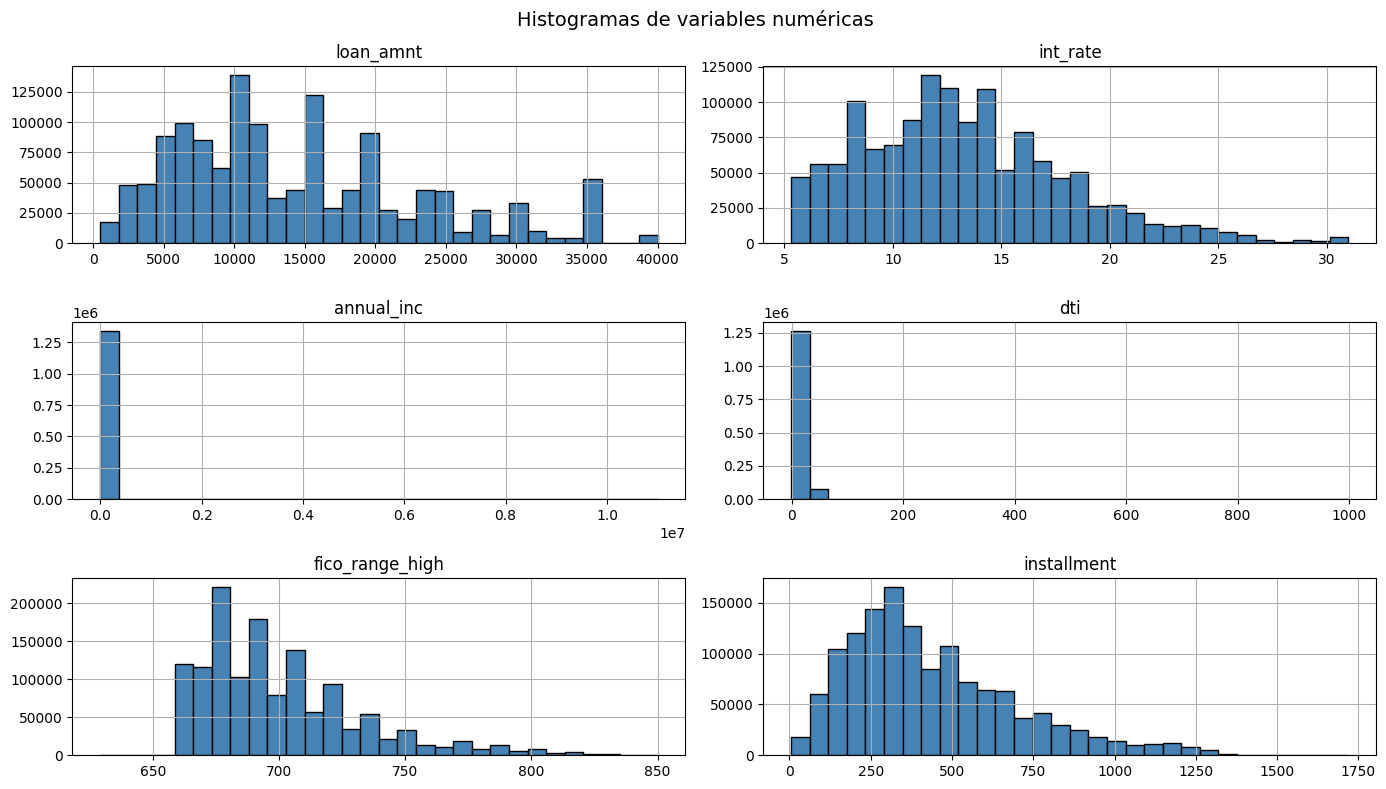

In [10]:
cols = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_high", "installment"]

df[cols].hist(bins=30, figsize=(14, 8), color="steelblue", edgecolor="black")
plt.suptitle("Histogramas de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

La variable `loan_amnt` muestra una distribucion con picos en 10.000, 15.000 y 20.000. `int_rate` presenta una distribucion aproxidamente normal cnetrada entre 10% y 15%. `annual_inc` y `dti` muestran una dsitribucion fuertemente sesgada a la derecha, indicando la presencia de valores atipicos importantes. `fico_range` se concentra entre 650 y 750 puntos siendo este un credito moderado a bueno.`installment` tambien presenta sesgo a la derecha con la mayoria de cuotas mensales por debajo de 500

#### Histogramas de variables numericas filtrado
Como se observaba, las variables `dti` y `annual_inc` no se podian visualizar bien debido a la presencia de valores atipicos extremos. Para corregir esto se aplicara un filtro eliminando el 1% superior de valores mas extremos de cada variable

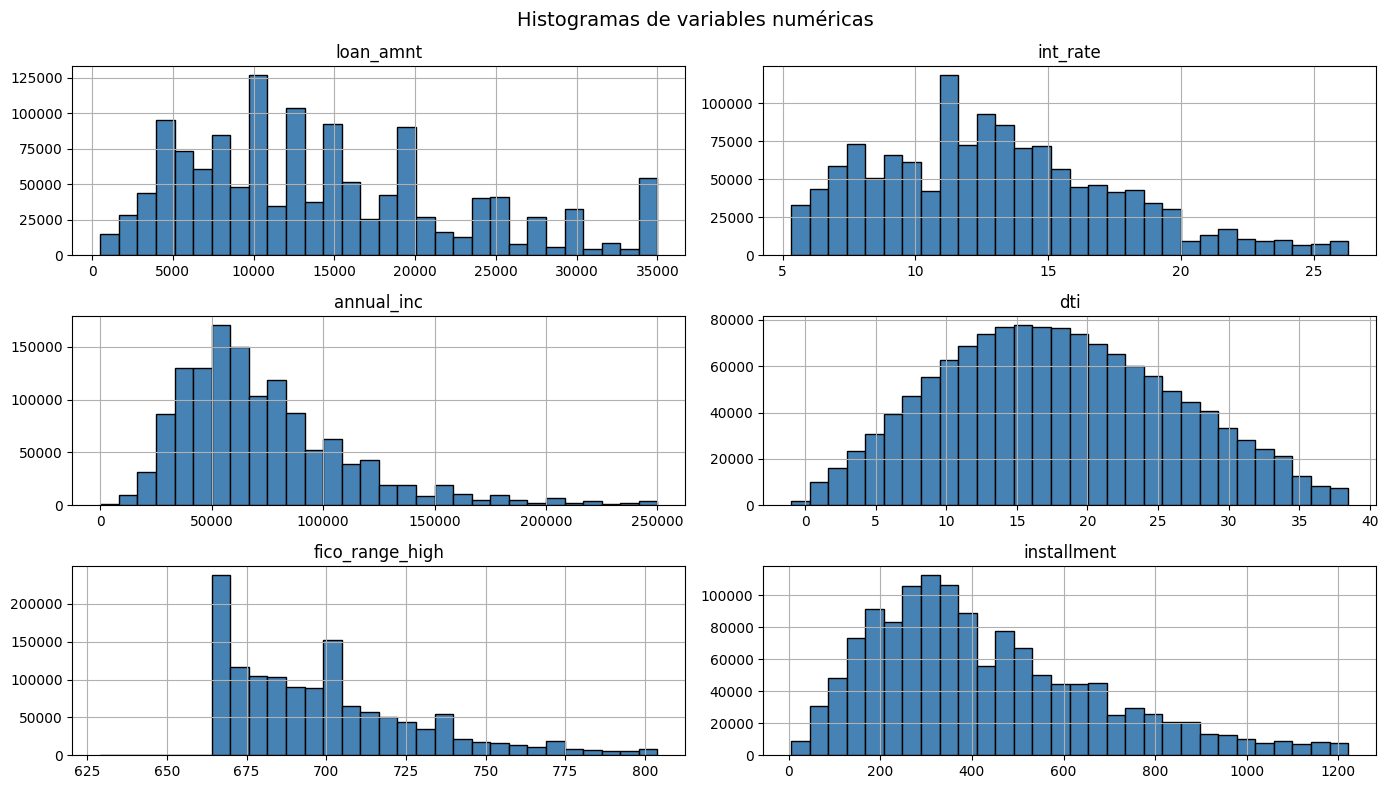

In [11]:
cols = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_high", "installment"]

df_plot = df[cols].apply(lambda x: x[x <= x.quantile(0.99)])

df_plot.hist(bins=30, figsize=(14, 8), color="steelblue", edgecolor="black")
plt.suptitle("Histogramas de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

Despues de eliminar el 1% superior de valores extremos, se puede ver mejor los graficos de `dti` y `annual_inc`. La variable `annual_inc` muestra que la mayoria de prestatarios tienen ingresos entre 40.000 y 80.000 con sesgo a la derecha. `dti` presenta una distribucion aproximadamente normal centrada entre 15 y 20, indicando una relacion deuda-ingreso "moderada"

### Boxplot por clase
En esta visualizacion se comparara la distribucion de cada variable entre prestamos pagados (0) y en default (1).

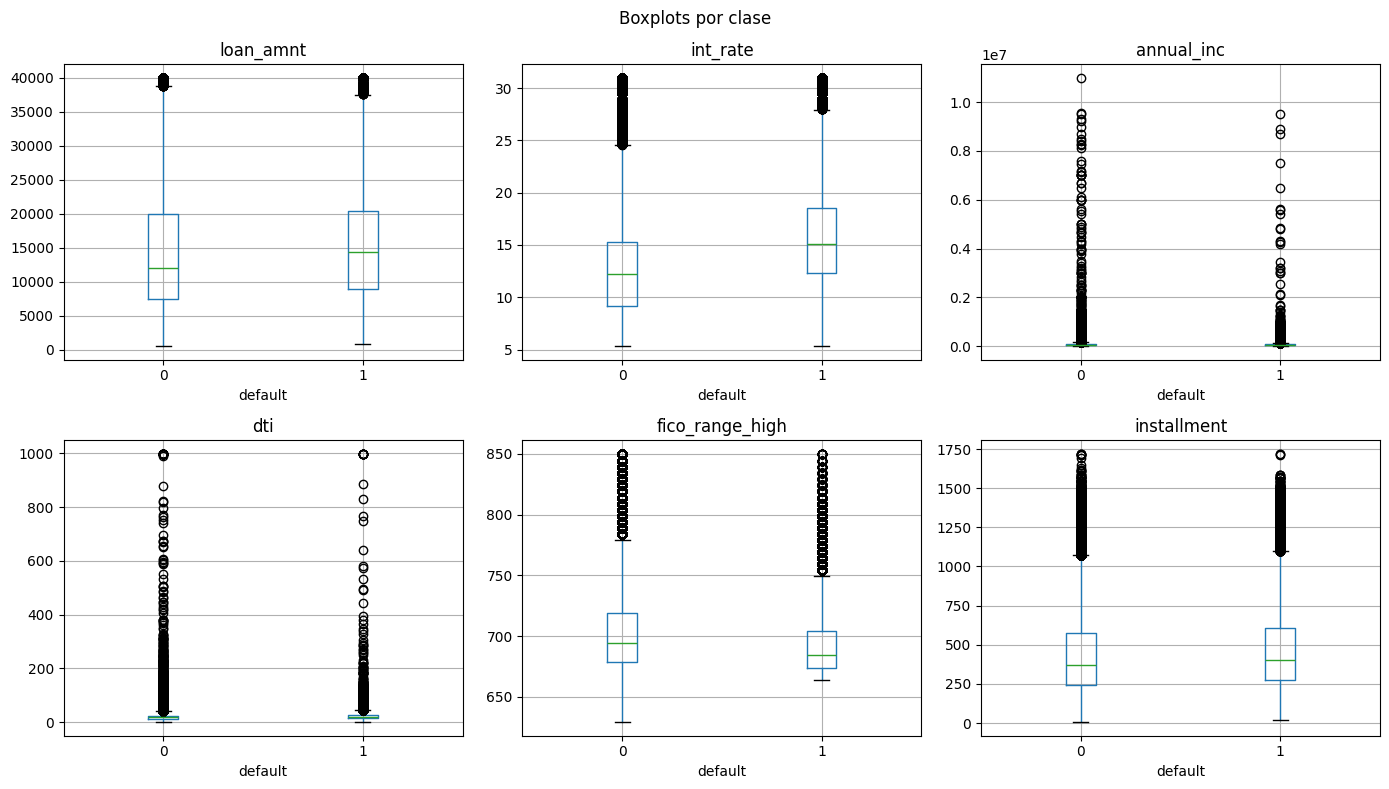

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    df.boxplot(column=col, by="default", ax=axes[i])

plt.suptitle("Boxplots por clase")
plt.tight_layout()
plt.show()

El boxplot muestra que `loan_amnt` presenta una distribucion similar entre ambas clsaes, con medianas alrededor de 12.000 para pagados y 14.000 para default, indicando que los prestamos en default tienden a ser ligeramente mayores. `int_rate` muestra una diferencia signficativa entre clases, con la mediana de los default mucho mas alta que la de los pagados, indicando que una tasa de interes mas alta estan asociadas a mayor probabilidad de incumplimiento. `annual_inc` y `dti` no se alcanzan a visualizar bien debido a valores atipicos extremos. `fico_range_high` muestra que los prestamos pagados tienen puntajes de credito mas altos que los defaults. `installment`presenta distribuciones muy similares entre ambas clases con outliers extremos que hacen complicada la comparacion

#### Boxplot por clase filtrado

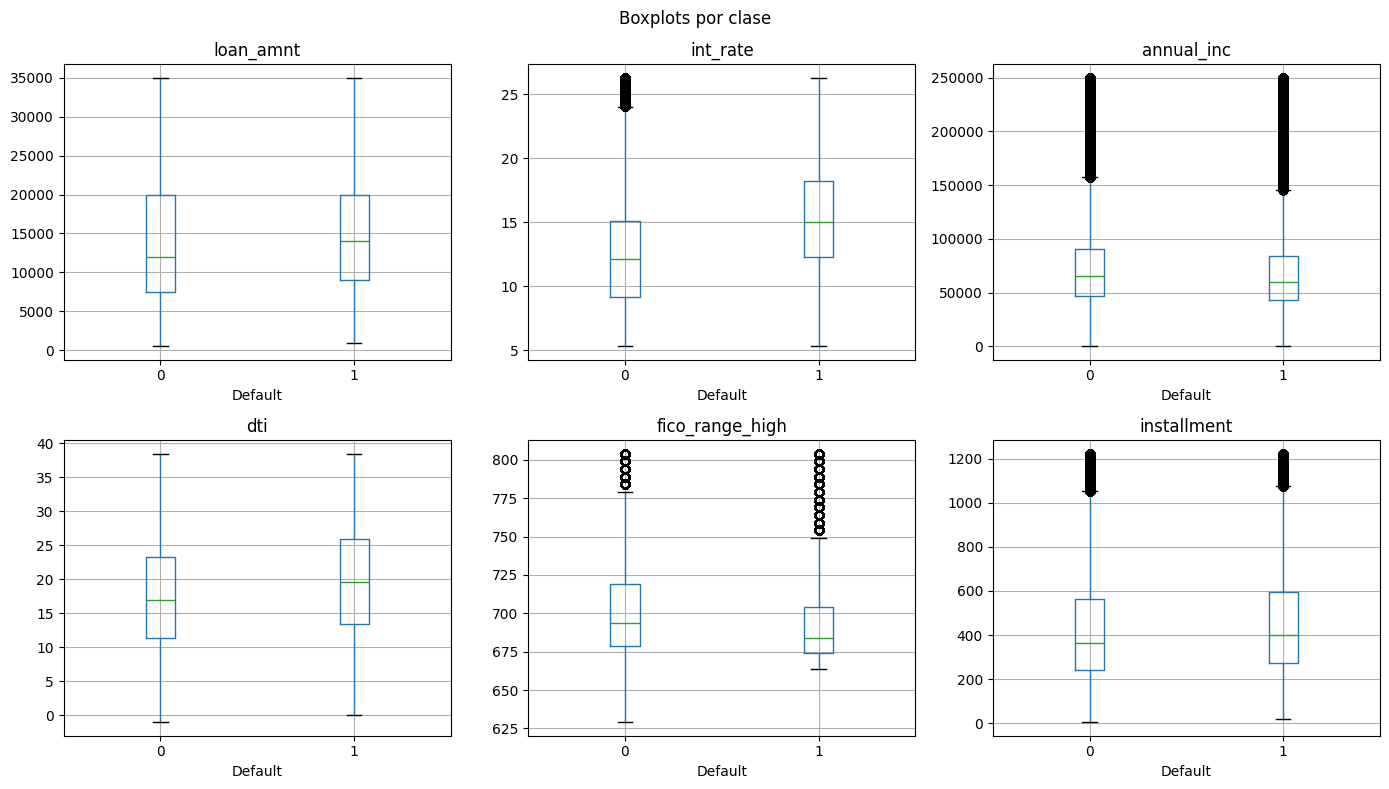

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    q99 = df[col].quantile(0.99)
    df_plot = df[df[col] <= q99]
    df_plot.boxplot(column=col, by="default", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Default")

plt.suptitle("Boxplots por clase")
plt.tight_layout()
plt.show()

Despues de aplicar el filtro del 99% se pueden apreciar mejor las variables `dti`, `annual_inc` e `installment`. `dti` nos muestra que los default tienen una relacion deuda-ingreso mayor con mediana cercana a 20 y 17 los pagados, indicando que mayor endeudamiento relativo esta asociado con un mayor riesgo. `annual_inc`muestra que ambas clases tienen ingresos similares con medianas alrededor de 60.000 aunque se ve que los pagados tienen una distribucion un poco mas alta. `installment` muestra una distribucion simiilar entre clases con medianas alrededor de 400.

### Correlacion
En esta visualizacion se podra ver que variables numericas estan mas relacionadas entre si y con la variable objetivo.

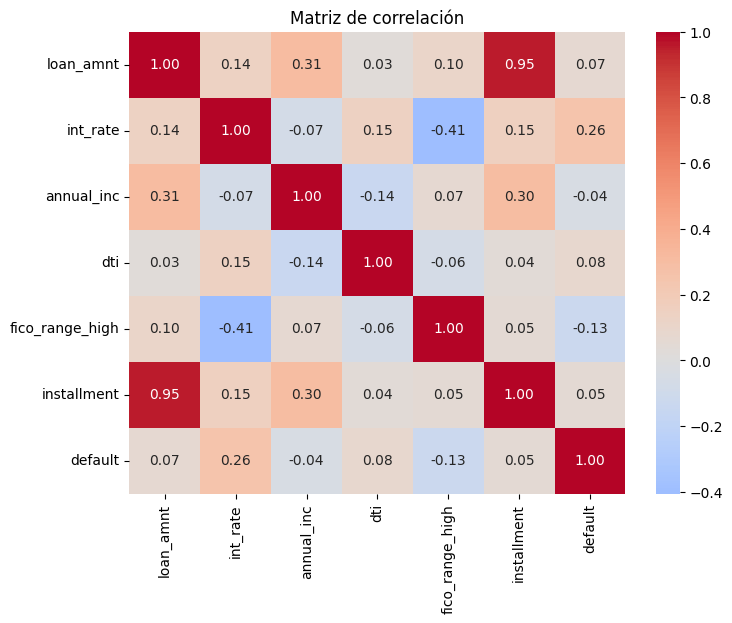

In [14]:
corr = df[cols + ["default"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

`loan_amnt`e `installment` tienen una correlacion muy alta de 0.95 lo cual es esperado ya que a mayor monto del prestamo mayor cuota mensual. `int_rate`y `fico_range_high`tienen una correlacion negativa de -0.41, indicando que prestatarias con mejor puntaje crediticio reciben tasas de interes mas bajas

Con respecto a la variable objetivo `default`, `int_rate`es la que muestra mayor relacion positiva con 0.26, es decir, las tasas mas altas estan asociadas a mayor probabilidad de incumplimiento. `fico_range_high` muestra correlacion de -0.13 sugiriendo que mejores puntajees crediticios estan asociados a menor probabilidad de default. El resto de variables muestran correlaciones muy bajas con `default`

### Distribucion de la variable objetivo 


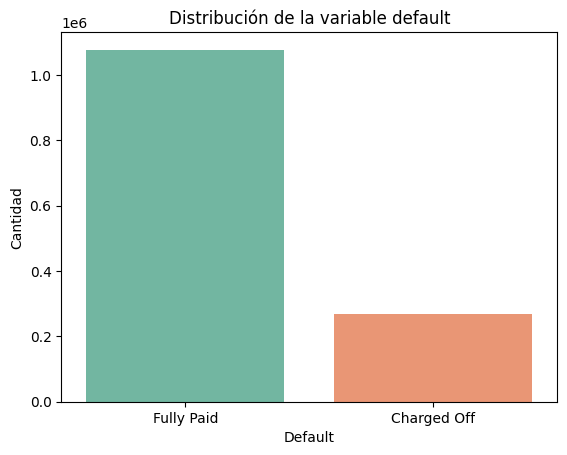

In [15]:
sns.countplot(x="default", data=df, palette="Set2")
plt.title("Distribución de la variable default")
plt.xlabel("Default")
plt.ylabel("Cantidad")
plt.xticks([0, 1], ["Fully Paid", "Charged Off"])
plt.show()

El grafico muestra la clase 0 (Fully Paid) cuenta con aproximadamente 1.050.00 registros mientras que la clase 1(Charged Off) tiene aproximadamente 260.000 registros representando el 80% y 20% respectivamente

### MUTUAL INFORMATION
Esto nos va ayudar a medir que tanto nos ayuda cada variable a predecir si un prestamo va a resultar en default. Si una variable tiene un valor alto significa que tiene contiene informacion util para el modelo, si tiene un valor cercano a 0 significa que no aporta nada y puede eliminarse

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Copia temporal para calcular MI sin modificar df original
df_temp = df.copy()

# Usamos label encoder para cambiar variables categóricas a numéricas en el df temporal q d
le = LabelEncoder()
categoricas = [col for col in df_temp.columns if df_temp[col].dtype == object or str(df_temp[col].dtype) == 'string' or df_temp[col].apply(type).eq(str).any()]


for col in categoricas:
    df_temp[col] = le.fit_transform(df_temp[col].astype(str))

# Mutual Information sobre todas las variables
X_temp = df_temp.drop(columns=["default"])
mi = mutual_info_classif(X_temp.fillna(0), df_temp["default"], random_state=42)
mi_series = pd.Series(mi, index=X_temp.columns).sort_values(ascending=False)

print(mi_series)

Los resultados muestran que `policy_code`tiene el valor mas alto con 0.20 seguido de `initial_list_status`con 0.14 y `home_ownership` con 0.09. A continuacion se eliminaran las variables con mutual information menor a 0.01